# Introduction to Agents with LangGraph

## Context

LangChain simplifies LLM application development, especially for agents that automate tasks.

While agents offer exciting possibilities, building reliable systems is challenging. To provide more control for production-ready agents, [LangGraph](https://langchain-ai.github.io/langgraph/) was developed as a separate framework. It enables precise control over agent workflows, like forcing specific tool calls or adapting prompts based on state.

## Initial Setup

In [1]:
# !uv pip install langchain_tavily
## You also need to set up the Tavily API Key

In [2]:
import os, getpass
from dotenv import load_dotenv 
load_dotenv(override=True)

True

In [3]:
#Check for Groq API Key
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("GROQ API Key: ")

## Chat Models

In [4]:
!ollama pull llama3.2

]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest 
pulling dde5aa3fc5ff: 100% ▕██████████████████▏ 2.0 GB                         
pulling 966de95ca8a6: 100% ▕██████████████████▏ 1.4 KB                         
pulling fcc5a6bec9da: 100% ▕██████████████████▏ 7.7 KB                         
pulling a70ff7e570d9: 100% ▕██████████████████▏ 6.0 KB                         
pulling 56bb8bd477a5: 100% ▕██████████████████▏   96 B                         
pulling 34bb5ab01051: 100% ▕██████████████████▏  561 B                         
verifying sha256 digest 
writing manifest 
success 


In [7]:
from langchain.chat_models import init_chat_model

model_name = "openai/gpt-oss-120b"
llm = init_chat_model(model_name, model_provider="groq") #Other Llama alternatives available are llama3-8b-8192, llama-3.3-70b-versatile

## Search Tools

[Tavily](https://tavily.com/) is a search engine designed for LLMs and RAG that provides efficient, fast, and consistent search results. It's simple to sign up for and includes a generous free tier. 

In [8]:
#Check for Tavily API Key
if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass.getpass("TAVILY API Key: ")

TAVILY API Key:  ········


In [9]:
from langchain_tavily import TavilySearch
tavily_search = TavilySearch(max_results=3)
search_docs = tavily_search.invoke("What is the weather in Ulwe today?")

In [10]:
search_docs

{'query': 'What is the weather in Ulwe today?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'Weather in Ulwe',
   'url': 'https://www.weatherapi.com/',
   'content': "{'error': {'code': 1006, 'message': 'No matching location found.'}}",
   'score': 0.9720867,
   'raw_content': None,
   'id': '0a29ed-00'},
  {'url': 'https://www.aqi.in/weather/us/india/maharashtra/navi-mumbai',
   'title': 'Navi Mumbai Weather Conditions: Temperature | 30 Days Forecast',
   'content': "3.6 kmph /  NW\n\npatchy rain possible\n\n3.6 kmph /  NW\n\npatchy rain possible\n\n3.6 kmph /  WNW\n\npatchy rain possible\n\n3.6 kmph /  WNW\n\n## India's Hottest Cities - September 2026\n\n1.\n\nIndia flagThoothukudi, Tamil Nadu\n\nIndia flag\n\n29 °C\n\npatchy rain possiblePatchy rain nearby\n\npatchy rain possible\n\nHumidity Icon69%\n\nHumidity Icon\n\nUV Icon0\n\nUV Icon\n\n17.3 kmph /  W\n\n2.\n\nIndia flagBikaner, Rajasthan\n\nIndia flag\n\n29 °C\n\nclearClear\n\nclear\n\n

# The Simplest Graph

Let's build a simple graph with 3 nodes and one conditional edge. 

![Screenshot 2024-08-20 at 3.11.22 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dba5f465f6e9a2482ad935_simple-graph1.png)

## State

First, define the [State](https://langchain-ai.github.io/langgraph/concepts/low_level/#state) of the graph. 

The State schema serves as the input schema for all Nodes and Edges in the graph.

Let's use the `TypedDict` class from python's `typing` module as our schema, which provides type hints for the keys.

In [11]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_state: str

## Nodes

[Nodes](https://langchain-ai.github.io/langgraph/concepts/low_level/#nodes) are just python functions.

The first positional argument is the state, as defined above.

Because the state is a `TypedDict` with schema as defined above, each node can access the key, `graph_state`, with `state['graph_state']`.

Each node returns a new value of the state key `graph_state`.
  
By default, the new value returned by each node [will override](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers) the prior state value.

In [12]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}

## Edges

[Edges](https://langchain-ai.github.io/langgraph/concepts/low_level/#edges) connect the nodes.

Normal Edges are used if you want to *always* go from, for example, `node_1` to `node_2`.

[Conditional Edges](https://langchain-ai.github.io/langgraph/reference/graphs/?h=conditional+edge#langgraph.graph.StateGraph.add_conditional_edges) are used want to *optionally* route between nodes.
 
Conditional edges are implemented as functions that return the next node to visit based upon some logic.

In [13]:
import random
from typing import Literal

def decide_mood(state) -> Literal["node_2_test", "node_3_test"]:
    
    # Often, we will use state to decide on the next node to visit
    user_input = state['graph_state'] 
    
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:

        # 50% of the time, we return Node 2
        return "node_2_test"
    
    # 50% of the time, we return Node 3
    return "node_3_test"

## Graph Construction

Now, we build the graph from our [components](
https://langchain-ai.github.io/langgraph/concepts/low_level/) defined above.

The [StateGraph class](https://langchain-ai.github.io/langgraph/concepts/low_level/#stategraph) is the graph class that we can use.
 
First, we initialize a StateGraph with the `State` class we defined above.
 
Then, we add our nodes and edges.

We use the [`START` Node, a special node](https://langchain-ai.github.io/langgraph/concepts/low_level/#start-node) that sends user input to the graph, to indicate where to start our graph.
 
The [`END` Node](https://langchain-ai.github.io/langgraph/concepts/low_level/#end-node) is a special node that represents a terminal node. 

Finally, we [compile our graph](https://langchain-ai.github.io/langgraph/concepts/low_level/#compiling-your-graph) to perform a few basic checks on the graph structure. 

We can visualize the graph as a [Mermaid diagram](https://github.com/mermaid-js/mermaid).

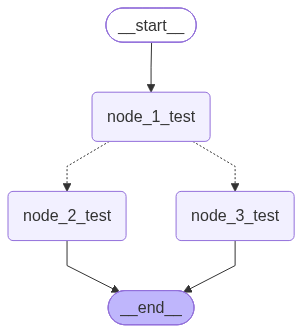

In [14]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Build graph
builder = StateGraph(State) ##State is a custom class, defined by us, containing the variables that are part of the Graph State. It inherits from either Pydantic or TypedDict.
builder.add_node("node_1_test", node_1)
builder.add_node("node_2_test", node_2)
builder.add_node("node_3_test", node_3)

# Logic
builder.add_edge(START, "node_1_test")
builder.add_conditional_edges("node_1_test", decide_mood)
builder.add_edge("node_2_test", END)
builder.add_edge("node_3_test", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
type(builder)

langgraph.graph.state.StateGraph

In [16]:
type(graph)

langgraph.graph.state.CompiledStateGraph

## Graph Invocation

The compiled graph implements the [runnable](https://python.langchain.com/v0.1/docs/expression_language/interface/) protocol.

This provides a standard way to execute LangChain components. 
 
`invoke` is one of the standard methods in this interface.

The input is a dictionary `{"graph_state": "Hi, this is Anant."}`, which sets the initial value for our graph state dict.

When `invoke` is called, the graph starts execution from the `START` node.

It progresses through the defined nodes (`node_1`, `node_2`, `node_3`) in order.

The conditional edge will traverse from node `1` to node `2` or `3` using a 50/50 decision rule. 

Each node function receives the current state and returns a new value, which overrides the graph state.

The execution continues until it reaches the `END` node.

In [17]:
graph.invoke({"graph_state" : "Hi."})

---Node 1---
---Node 2---


{'graph_state': 'Hi. I am happy!'}

`invoke` runs the entire graph synchronously.

This waits for each step to complete before moving to the next.

It returns the final state of the graph after all nodes have executed.

In this case, it returns the state after `node_3` has completed: 

```
{'graph_state': 'Hi, this is Anant. I am sad!'}
```

# Chain

## Review

We built a simple graph with nodes, normal edges, and conditional edges.

## Goals

Now, let's build up to a simple chain that combines 4 [concepts](https://python.langchain.com/v0.2/docs/concepts/):

* Using [chat messages](https://python.langchain.com/v0.2/docs/concepts/#messages) as our graph state
* Using [chat models](https://python.langchain.com/v0.2/docs/concepts/#chat-models) in graph nodes
* [Binding tools](https://python.langchain.com/v0.2/docs/concepts/#tools) to our chat model
* [Executing tool calls](https://python.langchain.com/v0.2/docs/concepts/#functiontool-calling) in graph nodes 

![Screenshot 2024-08-21 at 9.24.03 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dd607b08df5e1101_chain1.png)

## Messages

Chat models can use [`messages`](https://python.langchain.com/v0.2/docs/concepts/#messages), which capture different roles within a conversation. 

LangChain supports various message types, including `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`. 

These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call. 

Let's create a list of messages. 

Each message can be supplied with a few things:

* `content` - content of the message
* `name` - optionally, a message author 
* `response_metadata` - optionally, a dict of metadata (e.g., often populated by model provider for `AIMessages`)

In [18]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Anant"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Anant"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Anant

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Anant

I want to learn about the best place to see Orcas in the US.


In [19]:
response = llm.invoke(messages)

In [20]:
response

AIMessage(content='## Where to See Orcas (Killer Whales) in the United States  \n\n| State | Primary Viewing Area | Best Time of Year | Typical Orca Species | What You’ll See | How to Get There |\n|-------|----------------------|-------------------|----------------------|-----------------|-------------------|\n| **Washington** | **San Juan Islands** (especially Friday Harbor, Lime Kiln, and the waters around Orcas Island) | **May\u202f–\u202fOctober** (peak: June–August) | Resident “Southern Residents” (J‑pods, K‑pods, L‑pods) | Pods of 3‑30 animals, often with calves; they travel in tight, predictable patterns. | Fly into Seattle (SEA) → drive 1.5\u202fh to Anacortes → ferry to Friday Harbor (or drive 2\u202fh to Orcas Island). |\n| | **North Puget Sound** (e.g., Edmonds, Seattle’s Elliott Bay) | **Year‑round**, but best May‑Oct | Transient “Bigg’s” and occasional residents | Transients are more solitary or in small groups; you may spot them hunting seals. | Access via city marinas; m

In [21]:
#Check number of input / output tokens
response.response_metadata

{'token_usage': {'completion_tokens': 3072,
  'prompt_tokens': 127,
  'total_tokens': 3199,
  'completion_time': 6.438847551,
  'prompt_time': 0.00655848,
  'queue_time': 0.347301728,
  'total_time': 6.445406031,
  'completion_tokens_details': {'reasoning_tokens': 39}},
 'model_name': 'openai/gpt-oss-120b',
 'system_fingerprint': 'fp_f640395b96',
 'service_tier': 'on_demand',
 'finish_reason': 'length',
 'logprobs': None}

## Tools

Tools are useful whenever you want a model to interact with external systems.

External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language. 

When we bind an API, for example, as a tool we given the model awareness of the required input schema.

The model will choose to call a tool based upon the natural language input from the user. 

And, it will return an output that adheres to the tool's schema. 

[Many LLM providers support tool calling](https://python.langchain.com/v0.1/docs/integrations/chat/) and [tool calling interface](https://blog.langchain.dev/improving-core-tool-interfaces-and-docs-in-langchain/) in LangChain is simple. 
 
You can simply pass any Python `function` into `ChatModel.bind_tools(function)`.

![Screenshot 2024-08-19 at 7.46.28 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dc1c17a7a57f9960_chain2.png)

Let's showcase a simple example of tool calling!
 
The `multiply` function is our tool.

In [22]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

If we pass an input - e.g., `"What is 2 multiplied by 3"` - we see a tool call returned. 

The tool call has specific arguments that match the input schema of our function along with the name of the function to call.

```
{'arguments': '{"a":2,"b":3}', 'name': 'multiply'}
```

In [23]:
llm.invoke("What is 2 multiplied by 3?")

AIMessage(content='2 multiplied by 3 equals **6**.', additional_kwargs={'reasoning_content': 'The user asks a simple math question: 2*3 = 6. No policy issues. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 80, 'total_tokens': 123, 'completion_time': 0.092055479, 'prompt_time': 0.004214204, 'queue_time': 0.347907473, 'total_time': 0.096269683, 'completion_tokens_details': {'reasoning_tokens': 24}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4140daa9c2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--62e4b858-c6b8-49d2-8be8-a3834839d749-0', usage_metadata={'input_tokens': 80, 'output_tokens': 43, 'total_tokens': 123})

In [24]:
tool_call = llm_with_tools.invoke("What is 2 multiplied by 3")
tool_call

AIMessage(content='2\u202f×\u202f3\u202f=\u202f6.', additional_kwargs={'reasoning_content': 'The user asks: "What is 2 multiplied by 3". That\'s simple: 6. No need to call function, but could use function multiply. But we can just answer 6. Probably just answer.'}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 135, 'total_tokens': 199, 'completion_time': 0.153645482, 'prompt_time': 0.006159896, 'queue_time': 0.310137829, 'total_time': 0.159805378, 'completion_tokens_details': {'reasoning_tokens': 45}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5082008e34', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--c03b8b21-759e-4b4a-bfb3-7b09fadd8ee9-0', usage_metadata={'input_tokens': 135, 'output_tokens': 64, 'total_tokens': 199})

In [25]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Anant")])
tool_call

AIMessage(content='2 multiplied by 3 equals **6**.', additional_kwargs={'reasoning_content': 'The user asks "What is 2 multiplied by 3". Simple multiplication 2*3 = 6. Could answer directly. No need to call function.'}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 135, 'total_tokens': 188, 'completion_time': 0.112605359, 'prompt_time': 0.045286714, 'queue_time': 0.399734253, 'total_time': 0.157892073, 'completion_tokens_details': {'reasoning_tokens': 34}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_803c0ba83d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--fd18e0e6-8b10-494d-8e40-ce066bad3347-0', usage_metadata={'input_tokens': 135, 'output_tokens': 53, 'total_tokens': 188})

## Using messages as state

With these foundations in place, we can now use [`messages`](https://python.langchain.com/v0.2/docs/concepts/#messages) in our graph state.

Let's define our state, `MessagesState`, as a `TypedDict` with a single key: `messages`.

`messages` is simply a list of messages, as we defined above (e.g., `HumanMessage`, etc).

In [27]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage, AIMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

## Reducers

Now, we have a minor problem! 

As we discussed, each node will return a new value for our state key `messages`.

But, this new value will [will override](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers) the prior `messages` value.
 
As our graph runs, we want to **append** messages to to our `messages` state key.
 
We can use [reducer functions](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers) address this.

Reducers allow us to specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should *override it* as we saw before.
 
But, to append messages, we can use the pre-built `add_messages` reducer.

This ensures that any messages are appended to the existing list of messages.

We annotate simply need to annotate our `messages` key with the `add_messages` reducer function as metadata.

In [28]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages] #reducer function

Since having a list of messages in graph state is so common, LangGraph has a pre-built [`MessagesState`](https://langchain-ai.github.io/langgraph/concepts/low_level/#messagesstate)! 

`MessagesState` is defined: 

* With a pre-build single `messages` key
* This is a list of `AnyMessage` objects 
* It uses the `add_messages` reducer

We'll usually use `MessagesState` because it is less verbose than defining a custom `TypedDict`, as shown above.

In [29]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

To go a bit deeper, we can see how the `add_messages` reducer works in isolation.

In [30]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Anant")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='f2239a12-e317-4669-b25a-e64463553f74'),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Anant', id='00c26466-5173-463f-ae1d-c7c507c8bb3d'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='347205ae-da92-4c52-ae62-84d4ae9670e4')]

## Our graph

Now, lets use `MessagesState` with a graph.

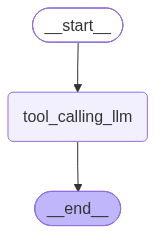

In [31]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

If we pass in `Hello!`, the LLM responds without any tool calls.

In [32]:
messages = graph.invoke({"messages": HumanMessage(content="Hello! How do you do?")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello! How do you do?
================================== Ai Message ==================================

Hello! I’m doing great, thank you for asking. How can I assist you today?


The LLM chooses to use a tool when it determines that the input or task requires the functionality provided by that tool.

In [33]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_6ee95df8-09dc-453a-ad2b-e4386eb46649)
 Call ID: fc_6ee95df8-09dc-453a-ad2b-e4386eb46649
  Args:
    a: 2
    b: 3


# Router

## Review

We built a graph that uses `messages` as state and a chat model with bound tools.

We saw that the graph can:

* Return a tool call
* Return a natural language response

## Goals

We can think of this as a router, where the chat model routes between a direct response or a tool call based upon the user input.

This is an simple example of an agent, where the LLM is directing the control flow either by calling a tool or just responding directly. 

![Screenshot 2024-08-21 at 9.24.09 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbac6543c3d4df239a4ed1_router1.png)

Let's extend our graph to work with either output! 

For this, we can use two ideas:

(1) Add a node that will call our tool.

(2) Add a conditional edge that will look at the chat model model output, and route to our tool calling node or simply end if no tool call is performed. 

In [34]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

In [35]:
llm_with_tools = llm.bind_tools([multiply])

 We use the [built-in `ToolNode`](https://langchain-ai.github.io/langgraph/reference/prebuilt/?h=tools+condition#toolnode) and simply pass a list of our tools to initialize it. 
 
 We use the [built-in `tools_condition`](https://langchain-ai.github.io/langgraph/reference/prebuilt/?h=tools+condition#tools_condition) as our conditional edge.

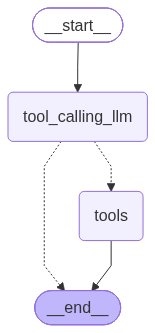

In [36]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
#Why is tool call occurring
from langchain_core.messages import HumanMessage, SystemMessage
messages = [HumanMessage(content="What is 2*2")] #SystemMessage(content="You are an expert at giving accurate answers and verify the answer always, if the question is on math."), 
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2*2
================================== Ai Message ==================================

2 × 2 = 4.


Now, we can see that the graph runs the tool!

It responds with a `ToolMessage`. 

# Agent

## Review

We built a router.

* Our chat model will decide to make a tool call or not based upon the user input
* We use a conditional edge to route to a node that will call our tool or simply end

![Screenshot 2024-08-21 at 12.44.33 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbac0ba0bd34b541c448cc_agent1.png)

## Goals

Now, we can extend this into a generic agent architecture.

In the above router, we invoked the model and, if it chose to call a tool, we returned a `ToolMessage` to the user.
 
But, what if we simply pass that `ToolMessage` *back to the model*?

We can let it either (1) call another tool or (2) respond directly.

This is the intuition behind [ReAct](https://react-lm.github.io/), a general agent architecture.
  
* `act` - let the model call specific tools 
* `observe` - pass the tool output back to the model 
* `reason` - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

This [general purpose architecture](https://blog.langchain.dev/planning-for-agents/) can be applied to many types of tools. 

![Screenshot 2024-08-21 at 12.45.43 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbac0b4a2c1e5e02f3e78b_agent2.png)

In [38]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]

# For this ipynb we set parallel tool calling to false as math generally is done sequentially, and this time we have 3 tools that can do math
# the OpenAI model specifically defaults to parallel tool calling for efficiency, see https://python.langchain.com/docs/how_to/tool_calling_parallel/
# play around with it and see how the model behaves with math equations!
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

Let's create our LLM and prompt it with the overall desired agent behavior.

In [39]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

As before, we use `MessagesState` and define a `Tools` node with our list of tools.

The `Assistant` node is just our model with bound tools.

We create a graph with `Assistant` and `Tools` nodes.

We add `tools_condition` edge, which routes to `End` or to `Tools` based on  whether the `Assistant` calls a tool.

Now, we add one new step:

We connect the `Tools` node *back* to the `Assistant`, forming a loop.

* After the `assistant` node executes, `tools_condition` checks if the model's output is a tool call.
* If it is a tool call, the flow is directed to the `tools` node.
* The `tools` node connects back to `assistant`.
* This loop continues as long as the model decides to call tools.
* If the model response is not a tool call, the flow is directed to END, terminating the process.

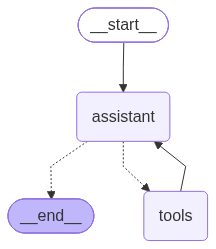

In [40]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [41]:
messages_input = [HumanMessage(content="What is 1 divided by 0?")]
messages_output = react_graph.invoke({"messages": messages_input})

In [42]:
for m in messages_output['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 1 divided by 0?
================================== Ai Message ==================================

Dividing any number by 0 is undefined in ordinary arithmetic—there’s no real (or finite) result for \( \frac{1}{0} \). In most mathematical contexts this operation is considered undefined (or “infinite” in a limiting sense), so it doesn’t have a meaningful numeric value.


# Agent memory

## Review

Previously, we built an agent that can:

* `act` - let the model call specific tools 
* `observe` - pass the tool output back to the model 
* `reason` - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

![Screenshot 2024-08-21 at 12.45.32 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab7453080e6802cd1703_agent-memory1.png)

## Goals

Now, we're going extend our agent by introducing memory.

In [43]:
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

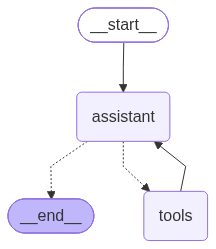

In [44]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

## Memory

Let's run our agent, as before.

In [45]:
messages = [HumanMessage(content="Add 3 and 4.")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (fc_ce05fbe7-3a42-488e-ac92-ee9c61647bce)
 Call ID: fc_ce05fbe7-3a42-488e-ac92-ee9c61647bce
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

7


Now, let's multiply by 2!

In [46]:
messages = [HumanMessage(content="Multiply that by 2.")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================

I’m not sure which number you’d like to multiply by 2. Could you please provide the value you’d like me to use?


We don't retain memory of 7 from our initial chat!

This is because [state is transient](https://github.com/langchain-ai/langgraph/discussions/352#discussioncomment-9291220) to a single graph execution.

Of course, this limits our ability to have multi-turn conversations with interruptions. 

We can use [persistence](https://langchain-ai.github.io/langgraph/how-tos/persistence/) to address this! 

LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update. 

One of the easiest checkpointers to use is the `MemorySaver`, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

In [47]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)

When we use memory, we need to specify a `thread_id`.

This `thread_id` will store our collection of graph states.

Here is a cartoon:

* The checkpointer write the state at every step of the graph
* These checkpoints are saved in a thread 
* We can access that thread in the future using the `thread_id`

![state.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e0e9f526b41a4ed9e2d28b_agent-memory2.png)


In [48]:
# Specify a thread
config = {"configurable": {"thread_id": "1"}}

# Specify an input
messages = [HumanMessage(content="Add 3 and 4.")]

# Run
messages = react_graph_memory.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (fc_5e909033-a939-4449-9336-fe6e8c119123)
 Call ID: fc_5e909033-a939-4449-9336-fe6e8c119123
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

7


If we pass the same `thread_id`, then we can proceed from from the previously logged state checkpoint! 

In this case, the above conversation is captured in the thread.

The `HumanMessage` we pass (`"Multiply that by 2."`) is appended to the above conversation.

So, the model now know that `that` refers to the `The sum of 3 and 4 is 7.`.

In [49]:
messages = [HumanMessage(content="Multiply that by 2.")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (fc_5e909033-a939-4449-9336-fe6e8c119123)
 Call ID: fc_5e909033-a939-4449-9336-fe6e8c119123
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

7
================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_5dbbba2b-b56a-43de-834a-628563b0b955)
 Call ID: fc_5dbbba2b-b56a-43de-834a-628563b0b955
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================

14


# Using Pre-built Agent

## Defining the Search Tool

In [50]:
from langchain_tavily import TavilySearch

search = TavilySearch(max_results=10)
search_results = search.invoke("what is the weather in SF")
print(search_results)
# If we want, we can create other tools.
# Once we have all the tools we want, we can put them in a list that we will reference later.
tools = [search]

{'query': 'what is the weather in SF', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.easeweather.com/north-america/united-states/california/city-and-county-of-san-francisco/september', 'title': 'September 2026 Weather - City and County of San Francisco', 'content': 'Until now, September 2026 in City and County of San Francisco has been nearly identical to the historical average, with a temperature of 20.4 °F (showing only a slight deviation of 0.2 °F).\n The forecast for the next days in City and County of San Francisco predicts temperatures to be around 18 °F, close to the historical average. [...] | 20 Weather Alert Overcast 16° | 21 Patchy rain possible 17° | 22 Sunny 18° | 23 Overcast 19° | 24 Overcast 18° | 25 Overcast 16° | 26 Sunny 18° |\n| 27 Sunny 23° | 28 Sunny 25° | 29 Sunny 19° | 30 Partly cloudy 17° | [...] | Sept. 25 | Overcast Overcast | 16° /14° | 0 mm | 5 |\n| Sept. 26 | Sunny Sunny | 18° /14° | 0 mm | 5 |\n| Sept. 27 | Sun

## Creating the Agent

In [51]:
from langgraph.prebuilt import create_react_agent

agent_executor = create_react_agent(llm, tools)

In [52]:
tools

[TavilySearch(max_results=10, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))]

## Running the Agent

In [53]:
response = agent_executor.invoke({"messages": [HumanMessage(content="hi! I am Anant")]})

response["messages"]

[HumanMessage(content='hi! I am Anant', additional_kwargs={}, response_metadata={}, id='e048d6ea-5c67-41e0-b179-535b58aac45c'),
 AIMessage(content='Hi Anant! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says hi and introduces themselves. We can greet back and ask how we can help. No tool needed.'}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 321, 'total_tokens': 377, 'completion_time': 0.11680916, 'prompt_time': 0.017377799, 'queue_time': 0.909812005, 'total_time': 0.134186959, 'completion_tokens_details': {'reasoning_tokens': 29}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e5b4e54fbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--5d16d541-1427-414a-81d4-03bc8b7e5ed9-0', usage_metadata={'input_tokens': 321, 'output_tokens': 56, 'total_tokens': 377})]

In [54]:
response = agent_executor.invoke(
    {"messages": [HumanMessage(content="Who am I?")]}
)
response["messages"]

[HumanMessage(content='Who am I?', additional_kwargs={}, response_metadata={}, id='9e880c50-3b9a-420c-8e35-875923d92eed'),
 AIMessage(content='I’m not able to identify you based on our conversation so far. If you’d like to share a bit about yourself—or let me know what you’re looking for—I’ll do my best to help!', additional_kwargs={'reasoning_content': 'The user asks "Who am I?" This is ambiguous. As ChatGPT, we don\'t have personal info. Should respond that I don\'t know, ask for clarification.'}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 319, 'total_tokens': 403, 'completion_time': 0.176831965, 'prompt_time': 0.017918169, 'queue_time': 0.210612387, 'total_time': 0.194750134, 'completion_tokens_details': {'reasoning_tokens': 34}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6dedd2be22', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--869de42c-b1b5-46ad-99ef-5b480cf5ec37-0', usage_metadata={'input_

## Adding in Memory

In [55]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [56]:
agent_executor = create_react_agent(llm, tools, checkpointer=memory)
config = {"configurable": {"thread_id": "abc123"}}

In [57]:
response = agent_executor.invoke({"messages": [HumanMessage(content="hi I am Anant!")]},config)

response["messages"]

[HumanMessage(content='hi I am Anant!', additional_kwargs={}, response_metadata={}, id='ce64d551-3183-40c0-ac63-8edcefb56c79'),
 AIMessage(content='Hi Anant! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi I am Anant!" Likely a greeting. Should respond friendly. No need to use tools.'}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 321, 'total_tokens': 372, 'completion_time': 0.115278785, 'prompt_time': 0.014743304, 'queue_time': 0.348238773, 'total_time': 0.130022089, 'completion_tokens_details': {'reasoning_tokens': 26}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_60e4b492db', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--2fc501c9-673a-4498-8ba3-2daf23eabd6a-0', usage_metadata={'input_tokens': 321, 'output_tokens': 51, 'total_tokens': 372})]

In [58]:
response = agent_executor.invoke({"messages": [HumanMessage(content="What's my name!")]},config)

response["messages"]

[HumanMessage(content='hi I am Anant!', additional_kwargs={}, response_metadata={}, id='ce64d551-3183-40c0-ac63-8edcefb56c79'),
 AIMessage(content='Hi Anant! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi I am Anant!" Likely a greeting. Should respond friendly. No need to use tools.'}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 321, 'total_tokens': 372, 'completion_time': 0.115278785, 'prompt_time': 0.014743304, 'queue_time': 0.348238773, 'total_time': 0.130022089, 'completion_tokens_details': {'reasoning_tokens': 26}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_60e4b492db', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--2fc501c9-673a-4498-8ba3-2daf23eabd6a-0', usage_metadata={'input_tokens': 321, 'output_tokens': 51, 'total_tokens': 372}),
 HumanMessage(content="What's my name!", additional_kwargs={}, response_metadata={}, id='f64b603a-ec82